# Importing all the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('max_columns', 200)

# Getting the data

In [3]:
df = pd.read_csv("extended_search_data.csv")

In [4]:
df.head()

,search_id,user_id,session_id,timestamp,search_term,device_type,search_source,results_returned,search_results,search_time_taken,clicked_result,clicked_result_name,conversion
0,1,5554,507697,2025-01-29 03:34:23.421222,coffee mug,Desktop,Homepage,True,"['Ceramic Mug', 'Travel Mug', 'Insulated Mug']",0.77,False,NaN,False
1,2,7188,563581,2025-01-10 20:35:16.421222,dresses,Mobile,Category Page,False,[],3.28,False,NaN,False
2,3,8857,391121,2025-02-01 12:43:27.421222,phone case,Mobile,Homepage,True,"['OtterBox Defender', 'Spigen Tough Armor', 'A...",0.30,False,NaN,False
3,4,1282,232523,2025-01-23 15:06:57.421222,smartphone,Mobile,Category Page,True,"['iPhone 15', 'Samsung Galaxy S24', 'Google Pi...",2.64,False,NaN,False
4,5,3466,370283,2025-01-13 06:10:53.421222,shoes,Tablet,Product Page,False,[],0.55,False,NaN,False


# Step 1: Data Understanding

In [5]:
df.shape

(5000, 13)

In [6]:
df.columns

Index(['search_id', 'user_id', 'session_id', 'timestamp', 'search_term',
       'device_type', 'search_source', 'results_returned', 'search_results',
       'search_time_taken', 'clicked_result', 'clicked_result_name',
       'conversion'],
      dtype='object')

In [7]:
df.dtypes

search_id                int64
user_id                  int64
session_id               int64
timestamp               object
search_term             object
device_type             object
search_source           object
results_returned          bool
search_results          object
search_time_taken      float64
clicked_result            bool
clicked_result_name     object
conversion                bool
dtype: object

In [8]:
df.describe()

,search_id,user_id,session_id,search_time_taken
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,5543.255200,523784.359400,1.869394
std,1443.520003,2614.656082,274152.611515,0.940462
min,1.000000,1001.000000,50063.000000,0.200000
25%,1250.750000,3306.750000,285340.750000,1.060000
50%,2500.500000,5584.500000,520898.000000,1.900000
75%,3750.250000,7779.000000,759352.500000,2.670000
max,5000.000000,9999.000000,999434.000000,3.500000


# Step 2: Data Prepration

In [9]:
df.tail()

,search_id,user_id,session_id,timestamp,search_term,device_type,search_source,results_returned,search_results,search_time_taken,clicked_result,clicked_result_name,conversion
4995,4996,5202,83522,2025-01-13 14:37:31.421222,coffee mug,Mobile,Category Page,True,"['Ceramic Mug', 'Travel Mug', 'Insulated Mug']",2.24,True,Ceramic Mug,False
4996,4997,8638,192988,2025-01-26 05:29:32.421222,keyboard,Mobile,Product Page,True,"['Logitech MX Keys', 'Razer BlackWidow', 'Cors...",3.21,True,Razer BlackWidow,False
4997,4998,2491,90490,2025-01-12 05:53:49.421222,socks,Desktop,Homepage,False,[],2.69,False,NaN,False
4998,4999,2750,367602,2025-01-19 19:09:30.421222,gaming chair,Mobile,Category Page,True,"['DXRacer', 'Secretlab Titan', 'Razer Iskur']",0.85,False,NaN,False
4999,5000,3823,937126,2025-01-18 11:46:34.421222,dresses,Tablet,Category Page,False,[],2.80,False,NaN,False


In [10]:
df.isna().sum()

search_id                 0
user_id                   0
session_id                0
timestamp                 0
search_term               0
device_type               0
search_source             0
results_returned          0
search_results            0
search_time_taken         0
clicked_result            0
clicked_result_name    2485
conversion                0
dtype: int64

In [11]:
df.loc[df.duplicated()]

,search_id,user_id,session_id,timestamp,search_term,device_type,search_source,results_returned,search_results,search_time_taken,clicked_result,clicked_result_name,conversion


# Step 3: Feature Understanding

In [12]:
df.head()

,search_id,user_id,session_id,timestamp,search_term,device_type,search_source,results_returned,search_results,search_time_taken,clicked_result,clicked_result_name,conversion
0,1,5554,507697,2025-01-29 03:34:23.421222,coffee mug,Desktop,Homepage,True,"['Ceramic Mug', 'Travel Mug', 'Insulated Mug']",0.77,False,NaN,False
1,2,7188,563581,2025-01-10 20:35:16.421222,dresses,Mobile,Category Page,False,[],3.28,False,NaN,False
2,3,8857,391121,2025-02-01 12:43:27.421222,phone case,Mobile,Homepage,True,"['OtterBox Defender', 'Spigen Tough Armor', 'A...",0.30,False,NaN,False
3,4,1282,232523,2025-01-23 15:06:57.421222,smartphone,Mobile,Category Page,True,"['iPhone 15', 'Samsung Galaxy S24', 'Google Pi...",2.64,False,NaN,False
4,5,3466,370283,2025-01-13 06:10:53.421222,shoes,Tablet,Product Page,False,[],0.55,False,NaN,False


In [13]:
df.shape

(5000, 13)

In [14]:
df.search_id.value_counts()

2047    1
2608    1
4647    1
2600    1
553     1
       ..
3263    1
1218    1
3267    1
1222    1
2049    1
Name: search_id, Length: 5000, dtype: int64

Looks like all the search id are unique in this dataset. This si the Primary Key in the dataset

In [15]:
df.user_id.value_counts()

6427    5
2864    5
8187    4
1535    4
5512    4
       ..
1078    1
5168    1
3115    1
7209    1
8196    1
Name: user_id, Length: 3891, dtype: int64

The users can have more than one session in this dataset

In [16]:
df.session_id.value_counts()

235184    2
995778    2
991405    2
426155    2
921010    2
         ..
802137    1
189786    1
795401    1
464220    1
604724    1
Name: session_id, Length: 4982, dtype: int64

Looks like the session id is shared with different users. May need some analysis here.

In [17]:
df.timestamp.value_counts()

2025-01-11 08:55:19.421222    2
2025-01-11 08:13:36.421222    2
2025-01-15 09:18:06.421222    2
2025-02-02 20:27:46.421222    1
2025-02-01 05:22:53.421222    1
                             ..
2025-02-02 16:18:18.421222    1
2025-01-23 23:13:23.421222    1
2025-01-28 10:22:01.421222    1
2025-01-14 10:42:16.421222    1
2025-01-20 09:42:58.421222    1
Name: timestamp, Length: 4997, dtype: int64

There can be more than one event at the same time which is quite possible

In [18]:
df.search_term.value_counts()

water bottle           392
laptop                 370
gaming chair           368
wireless earbuds       368
mouse                  367
phone case             364
socks                  359
shoes                  353
smartphone             350
headphones             346
coffee mug             345
keyboard               341
external hard drive    340
dresses                337
Name: search_term, dtype: int64

There are 14 search terms which the visitors looked for. With the most popular being water bottle

In [19]:
df.device_type.value_counts()

Desktop    1685
Mobile     1677
Tablet     1638
Name: device_type, dtype: int64

Maximum number of searches are from Desktop but it does not differ a lot from Mobile and Tablet. The users use all the platforms.

In [20]:
df.search_source.value_counts()

Product Page     1678
Homepage         1664
Category Page    1658
Name: search_source, dtype: int64

The visitors use search functionality on Product Page, Homepage and Category Page.

In [21]:
df.results_returned.value_counts()

True     3559
False    1441
Name: results_returned, dtype: int64

In [22]:
df.results_returned.value_counts(normalize=True)*100

True     71.18
False    28.82
Name: results_returned, dtype: float64

The website returns no data around 29% of the time

In [23]:
df.search_results.value_counts()

[]                                                                     1441
['Dell XPS 13', 'MacBook Air', 'HP Spectre x360']                       370
['AirPods Pro', 'Sony WF-1000XM4', 'Bose QuietComfort Earbuds']         368
['DXRacer', 'Secretlab Titan', 'Razer Iskur']                           368
['Logitech MX Master 3', 'Razer DeathAdder', 'SteelSeries Rival 5']     367
['OtterBox Defender', 'Spigen Tough Armor', 'Apple Silicone Case']      364
['iPhone 15', 'Samsung Galaxy S24', 'Google Pixel 8']                   350
['Sony WH-1000XM5', 'Bose 700', 'Sennheiser Momentum 4']                346
['Ceramic Mug', 'Travel Mug', 'Insulated Mug']                          345
['Logitech MX Keys', 'Razer BlackWidow', 'Corsair K95']                 341
['Seagate 2TB', 'WD My Passport', 'Samsung T7']                         340
Name: search_results, dtype: int64

[] 1441 concludes that the data is aligns with the Returned result field

This fields gives the list of the results that came with the search

In [24]:
df.search_time_taken.describe()

count    5000.000000
mean        1.869394
std         0.940462
min         0.200000
25%         1.060000
50%         1.900000
75%         2.670000
max         3.500000
Name: search_time_taken, dtype: float64

The maximum time taken for the search results to come back was 3.5 sec

In [25]:
df.clicked_result.value_counts(normalize=True)

True     0.503
False    0.497
Name: clicked_result, dtype: float64

There is 50% chance that visitor will click on the search results.

In [26]:
df.clicked_result_name.value_counts()

WD My Passport               98
Bose QuietComfort Earbuds    96
Logitech MX Master 3         96
MacBook Air                  94
Secretlab Titan              94
Bose 700                     94
Razer DeathAdder             93
AirPods Pro                  93
DXRacer                      92
Google Pixel 8               89
Spigen Tough Armor           87
Apple Silicone Case          86
HP Spectre x360              85
Razer Iskur                  85
Insulated Mug                84
Ceramic Mug                  84
Razer BlackWidow             83
Dell XPS 13                  82
Corsair K95                  82
Sony WH-1000XM5              80
Seagate 2TB                  78
OtterBox Defender            77
Sony WF-1000XM4              77
Travel Mug                   76
SteelSeries Rival 5          76
Sennheiser Momentum 4        74
Samsung Galaxy S24           74
Samsung T7                   71
iPhone 15                    70
Logitech MX Keys             65
Name: clicked_result_name, dtype: int64

The top 3 products that visitors clicked on were WD My Passport, Logitech MX Master 3, Bose QuietComfort Earbuds.
And the least clicked products were Logitech MX Keys, iPhone 15 and Samsung T7

In [27]:
df.clicked_result_name.isna().sum()

2485

There are over 2000 events where the search results were not clicked on

In [28]:
df.conversion.value_counts()

False    4501
True      499
Name: conversion, dtype: int64

In [29]:
df.conversion.value_counts(normalize=True)

False    0.9002
True     0.0998
Name: conversion, dtype: float64

Around 10% of the time the clicks are converted into purchase

# Step 4: Feature Relationship

### 1. Identify which features influence search success, clicks and conversions.

In [30]:
correlation_matrix = df[['results_returned', 'clicked_result', 'conversion', 'search_time_taken']].corr()
print(correlation_matrix)

                   results_returned  clicked_result  conversion  \
results_returned           1.000000        0.640138    0.211867   
clicked_result             0.640138        1.000000    0.330971   
conversion                 0.211867        0.330971    1.000000   
search_time_taken         -0.005862       -0.011509    0.017528   

                   search_time_taken  
results_returned           -0.005862  
clicked_result             -0.011509  
conversion                  0.017528  
search_time_taken           1.000000  


<AxesSubplot:>

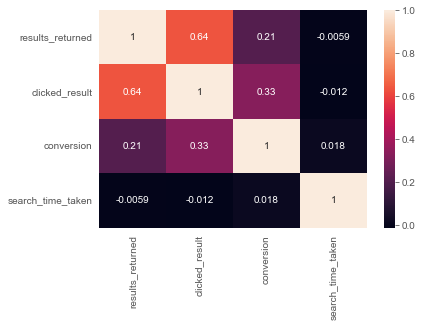

In [31]:
sns.heatmap(correlation_matrix, annot=True)

Strongest Correlation : Results_returned and clicked results has a moderate to strong correlation of 0.64. More search results returned tends to lead to more clicks on results.
Moderate Correlation: Clicked_results and conversion has a weak to moderate positive correlation of 0.33. Clicking on a search result somewhat increases the likelihood of conversion. Also, Returned_results and conversion has a weak positive correlation of 0.21. More results shown slightly increases conversions.
Very Weak Correlations: Search Time Taken has almost no correlation with results_returned, clicked_results or conversion, meaning the time taken for a search does not affect clicks or conversions.


Actionable Insights:
1. More results = More Clicks, if we want users to interact more, consider returning more relevant search results
2. Clicks somewhat predict conversions: Users who click on results are slightly more likely to convert, but other factors likely influence conversions more.
3. Search Time has no impact: Optimizing search speed might improve user experience, but it does not necessarily increase engagement or conversions.

### 2. Analyze how search behavior differ across devices

In [32]:
device_analysis = df.groupby("device_type").agg({
    "results_returned": "mean",
    "clicked_result": "mean",
    "search_time_taken": "mean"
}).rename(columns={
    "results_returned": "Success Rate",
    "clicked_result": "CTR",
    "search_time_taken": "Avg Search Time (s)"
})
print(device_analysis)

             Success Rate       CTR  Avg Search Time (s)
device_type                                             
Desktop          0.719881  0.514540             1.881062
Mobile           0.702445  0.487179             1.864067
Tablet           0.713065  0.507326             1.862845


Desktop (71.99%) has the highest success rate, followed by Tablet (71.31%) and Mobile (70.24%).
Mobile has the lowest success rate, possibly due to smaller screens, less intuitive navigation, or slower page loads.

Desktop (51.45%) has the highest CTR, indicating that desktop users engage more with search results.
Mobile has the lowest CTR (48.71%), suggesting that users either abandon searches more often or struggle to find relevant results.

Search time is nearly the same across devices (1.86–1.88s).
Since search times are similar, the differences in CTR and Success Rate are likely influenced by factors like screen size, ease of interaction, or search intent rather than time spent searching.

Actionable Insights:
1. Since Mobile has the lowest success Rate and CTR investigate the Mobile UI/UX.
2. Desktop users Desktop users click more and succeed more, maybe we should optimize desktop search experience for deeper enagagement like product recommendations.

### 3. Impact of Search Source

In [33]:
source_analysis = df.groupby('search_source').agg({
    "results_returned": "mean",
    "clicked_result": "mean",
    "conversion": "mean"
}).rename(columns={
    "results_returned": "Success Rate",
    "clicked_result": "CTR",
    "conversion": "Conversion Rate"
})
print(source_analysis)

               Success Rate       CTR  Conversion Rate
search_source                                         
Category Page      0.710495  0.501809         0.100121
Homepage           0.709135  0.506611         0.103365
Product Page       0.715733  0.500596         0.095948


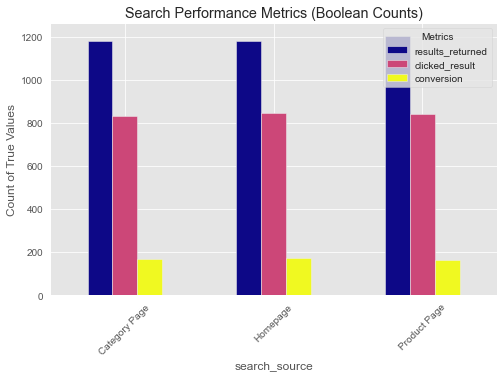

In [34]:
df_filtered = df[["search_source","results_returned", "clicked_result", "conversion" ]]
df_agg = df_filtered.groupby("search_source").sum()
df_agg.plot(kind='bar', figsize=(8, 5), colormap='plasma')

plt.title("Search Performance Metrics (Boolean Counts)")
plt.ylabel("Count of True Values")
plt.xticks(rotation=45)
plt.legend(title="Metrics", loc='upper right')
plt.show()

Product Page (71.57%) has the highest success rate, meaning searches from product pages return relevant results most often.
Homepage (70.91%) has the lowest success rate, indicating that searches from the homepage may be broader or less targeted.

Homepage has the highest CTR (50.66%), suggesting that users searching from the homepage are more likely to click on a result.
Product Page has the lowest CTR (50.06%), indicating that users searching from product pages might already be browsing and click less.

Homepage has the highest conversion rate (10.34%), meaning users searching from the homepage are more likely to complete a purchase.
Product Page has the lowest conversion rate (9.59%), which is surprising given that product pages usually indicate higher purchase intent.

Actionable Insights:
1. Homepage Search Optimization: High CTR and High Conversion rate indicates that users searching from the home page are engaged and convert well. Maybe we should consider improving the search relevance further to increase success rates.
2. Product PAge: Improve conversion Funnel, users search often but convert less suggesting they might not find what they need. The potential reasons can be improve product page recommendations

### 4. Effect of Search Response Time on Clicked Results and conversion

In [35]:
df['search_time_category'] = pd.cut(df['search_time_taken'], bins= [0,1,2,3,4], labels = ["Fast", "Moderate", "Slow", "Very Slow"])
search_term_analysis = df.groupby("search_time_category").agg({
    'clicked_result': 'mean',
    'conversion': 'mean'
}).rename(columns={
    'clicked_result' : 'CTR',
    'conversion' : 'conversion_rate'
})
print(search_term_analysis)

                           CTR  conversion_rate
search_time_category                           
Fast                  0.506849         0.100171
Moderate              0.516021         0.089453
Slow                  0.494697         0.106051
Very Slow             0.488372         0.106703


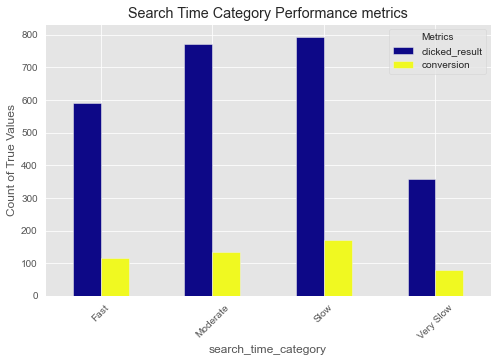

In [36]:
df_filtered = df[['search_time_category', 'clicked_result', 'conversion']]
df_agg = df_filtered.groupby('search_time_category').sum()
df_agg.plot(kind='bar', figsize=(8, 5), colormap='plasma')

plt.title("Search Time Category Performance metrics")
plt.ylabel("Count of True Values")
plt.xticks(rotation=45)
plt.legend(title="Metrics", loc='upper right')
plt.show()

Moderate search time has the highest CTR (51.6%), meaning searches that take a moderate amount of time lead to more clicks.
Very slow query time (48.8%) has the lowest CTR, suggesting that long processing times reduce engagement.

Very slow query times has the highest conversion rate (10.6%), meaning when queries take longer, the search results may be more refined, leading to better purchase decisions.
Moderate query times have the lowest conversion rate (8.9%), suggesting that although users engage more (high CTR), they may not find exactly what they need.

Actionable Insights:
1. Maintain optimized indexing to balance query speed & result quality.
2. Improve query performance with better caching, indexing, or query optimization.
3. Ensure high-quality, relevant search results even for slow queries.

### 5. Identify top-performing search items

In [37]:
top_search_items = df.groupby('search_term').agg({
    "results_returned": "mean",
    "clicked_result": "mean",
    "conversion": "mean"
}).sort_values(by="clicked_result", ascending=False)

print(top_search_items)

                     results_returned  clicked_result  conversion
search_term                                                      
gaming chair                     True        0.736413    0.165761
external hard drive              True        0.726471    0.132353
wireless earbuds                 True        0.722826    0.122283
mouse                            True        0.722071    0.152589
headphones                       True        0.716763    0.158960
coffee mug                       True        0.707246    0.127536
laptop                           True        0.705405    0.091892
phone case                       True        0.686813    0.145604
keyboard                         True        0.674487    0.146628
smartphone                       True        0.665714    0.160000
dresses                         False        0.000000    0.000000
shoes                           False        0.000000    0.000000
socks                           False        0.000000    0.000000
water bott

Highest CTR: gaming chair (73.6%)
Lowest CTR: Smartphones (66.6%)
Higher CTR for products like gaming chair, external hard drive, wireless buds, suggesting users are actively engaging with these searches.

Highest Conversion Rate: Gaming chair 16.6%
Lowest Conversion Rate: Laptop 9.1%
Wireless earbuds have high CTR (72.3%) but low conversion (12.2%) suggesting users click but hesitate to buy (maybe due to price, options or reviews.

Actionable Insights:
1. Prioritize gaming chairs in search ranking, optimize ads
2. Improve Product recommendations, emphasize discounts.

### 6. Understand user drop offs from searching to purchasing

In [38]:
searches = len(df)
successful_searches = df["results_returned"].sum()
clicks = df["clicked_result"].sum()
purchases =df["conversion"].sum()

print(f"Search Success Rate: {successful_searches / searches * 100:.2f}%")
print(f"Click-Through Rate (CTR): {clicks / successful_searches * 100:.2f}%")
print(f"Conversion Rate: {purchases / clicks * 100:.2f}%")

Search Success Rate: 71.18%
Click-Through Rate (CTR): 70.67%
Conversion Rate: 19.84%


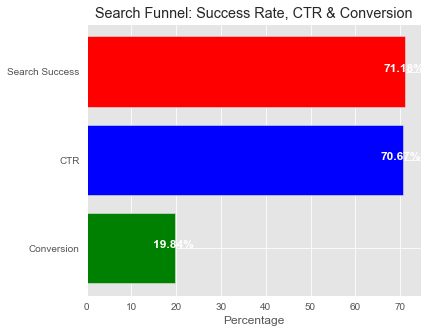

In [39]:
stages = ["Search Success", "CTR", "Conversion"]
values = [(successful_searches / searches * 100).round(2), (clicks / successful_searches * 100).round(2), (purchases / clicks * 100).round(2)]

plt.figure(figsize=(6,5))
plt.barh(stages[::-1], values[::-1], color=['green', 'blue', 'red'])

for i, v in enumerate(values[::-1]):
    plt.text(v - 5, i, f"{v:.2f}%", color='white', fontsize=12, fontweight='bold')

plt.xlabel("Percentage")
plt.title("Search Funnel: Success Rate, CTR & Conversion")
plt.show()

1. High Search Success Rate (71.8%)
Most searches return relevant results, however 28.8% of searches fail, indicating possible gaps in search indexing or product availability
2. Click-Through Rate (70.67%)
Most users click on results once they get search results, users trust the search output.
3. Lower Conversion Rate (19.84%)
There is a drop-off after engagement. Possible reasons could be: Pricing Issue, Trust Factors (lack of reviews, unclear product details) or Checkout friction

### 7. Identify Peak hours.


<AxesSubplot:title={'center':'Search Volume by Hour'}, xlabel='hour'>

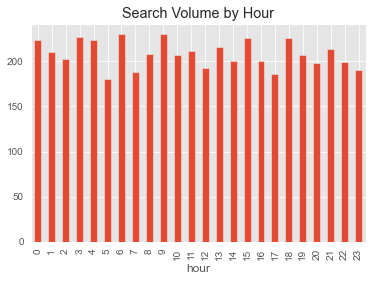

In [40]:
df["time"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["time"].dt.hour
search_trend = df.groupby("hour")["search_id"].count()

search_trend.plot(kind='bar', title="Search Volume by Hour")

The search activity is completely random during hours.

In [41]:
df.head()

,search_id,user_id,session_id,timestamp,search_term,device_type,search_source,results_returned,search_results,search_time_taken,clicked_result,clicked_result_name,conversion,search_time_category,time,hour
0,1,5554,507697,2025-01-29 03:34:23.421222,coffee mug,Desktop,Homepage,True,"['Ceramic Mug', 'Travel Mug', 'Insulated Mug']",0.77,False,NaN,False,Fast,2025-01-29 03:34:23.421222,3
1,2,7188,563581,2025-01-10 20:35:16.421222,dresses,Mobile,Category Page,False,[],3.28,False,NaN,False,Very Slow,2025-01-10 20:35:16.421222,20
2,3,8857,391121,2025-02-01 12:43:27.421222,phone case,Mobile,Homepage,True,"['OtterBox Defender', 'Spigen Tough Armor', 'A...",0.30,False,NaN,False,Fast,2025-02-01 12:43:27.421222,12
3,4,1282,232523,2025-01-23 15:06:57.421222,smartphone,Mobile,Category Page,True,"['iPhone 15', 'Samsung Galaxy S24', 'Google Pi...",2.64,False,NaN,False,Slow,2025-01-23 15:06:57.421222,15
4,5,3466,370283,2025-01-13 06:10:53.421222,shoes,Tablet,Product Page,False,[],0.55,False,NaN,False,Fast,2025-01-13 06:10:53.421222,6
